# 09-Multi-Container Grid Topologies (Docker Compose)

In Lesson 08, we engineered immutable filesystem layers using multi-stage Dockerfiles. We solved the environment drift paradox, ensuring that if an inference script or a feature extraction pipeline runs successfully on a local development workstation, it will execute identically on any production host.

However, modern enterprise machine learning applications do not live inside a single isolated container process. An operational machine learning system is a distributed network grid of microservices. For example, a real-time predictive service requires:

1. An **API Gateway / Serving Layer** (e.g., FastAPI) to receive incoming user requests and execute model forward passes.
2. An **In-Memory Cache Engine** (e.g., Redis) to store input feature vectors and log predictions, avoiding redundant calculations.
3. A **Persistent Relational Datastore** (e.g., PostgreSQL) to catalog telemetry logs, tracking drift metrics and historical inference states.

If you attempt to manage this multi-container system using imperative shell commands (`docker run`), manually managing private IP assignments, domain name system (DNS) mappings, and startup ordering constraints, your platform infrastructure will degrade due to synchronization complexity.

To resolve this, we leverage **Declarative Service Composition** via **Docker Compose**. We define our complete multi-container system architecture, isolated networking matrices, and disk persistence mounts as a single declarative state graph, allowing us to orchestrate multi-tier environments with zero infrastructure cost.

# 1. The Mathematics of Service Graphs & Network Isolation

### The Topology Graph ($\mathcal{G}$)

A multi-container grid can be formally modeled as a Directed Acyclic Graph (DAG) for initialization dependencies, super-imposed onto an undirected communication network graph:


$$\mathcal{G} = \langle \mathcal{V}, \mathcal{E}_{dep}, \mathcal{E}_{net} \rangle$$

* **Vertices ($\mathcal{V}$):** The set of independent container services $\{v_{\text{api}}, v_{\text{cache}}, v_{\text{db}}\}$.
* **Dependency Edges ($\mathcal{E}_{dep}$):** Directed edges representing initialization order constraints (`depends_on`). If $(v_{\text{cache}} \to v_{\text{api}}) \in \mathcal{E}_{dep}$, then $v_{\text{cache}}$ must transition to a healthy execution state before the kernel triggers the initialization of $v_{\text{api}}$.
* **Network Edges ($\mathcal{E}_{net}$):** Undirected edges defining cryptographic or logical communication boundaries.

### Network Overlay Partitions

To protect data integrity, we construct software-defined network partitions (bridges) directly inside the host's Linux kernel. Let our infrastructure be partitioned into two distinct subnets:


$$\mathcal{N}_{\text{frontend}}, \quad \mathcal{N}_{\text{backend}}$$

We mathematically enforce network isolation by defining service membership vectors:


$$\begin{aligned}
v_{\text{api}} &\in \{\mathcal{N}_{\text{frontend}}, \mathcal{N}_{\text{backend}}\} \\
v_{\text{cache}} &\in \{\mathcal{N}_{\text{backend}}\} \\
v_{\text{db}} &\in \{\mathcal{N}_{\text{backend}}\}
\end{aligned}$$

Because $v_{\text{db}}$ and $v_{\text{cache}}$ lack membership in $\mathcal{N}_{\text{frontend}}$, their internal port sockets are physically inaccessible to external internet routers. The API layer ($v_{\text{api}}$) acts as a strict mathematical proxy boundary.

### Port Projection Bi-junctions

To expose the internal serving layer to real-world clients, we define a port mapping function $f$ that maps a public port on the host's network socket directly to an internal private port container socket:


$$f(\mathbf{S}_{\text{host}} : \text{Port}_{\text{public}}) \longleftrightarrow \mathbf{S}_{\text{container}} : \text{Port}_{\text{private}}$$

# 2. Declarative Composition: The Grid Blueprint

Instead of managing infrastructure imperatively via fragile terminal commands, we express our entire multi-service state model inside a declarative `docker-compose.yml` blueprint.

Let's use Python to programmatically establish our orchestration sandbox and write the production-grade architectural manifest.

In [1]:
import subprocess
import os
import yaml

print("--- 🚀 Initializing Multi-Container Grid Orchestration Lab ---")

# Setup clean infrastructure sandbox
compose_sandbox = "./compose_sandbox"
os.makedirs(compose_sandbox, exist_ok=True)

# Define the declarative infrastructure graph
docker_compose_blueprint = {
    "version": "3.8",
    "services": {
        # 🧠 Service 1: The Prediction API Gateway Layer
        "inference-api": {
            "image": "python:3.10-slim",
            "container_name": "production_inference_api",
            "command": "python -c \"print('FastAPI server listening on port 8000...'); import time; time.sleep(3600)\"",
            "ports": [
                "8080:8000" # Maps host public port 8080 to container private port 8000
            ],
            "depends_on": {
                "feature-cache": {"condition": "service_started"},
                "telemetry-db": {"condition": "service_started"}
            },
            "networks": [
                "frontend_net",
                "backend_net"
            ],
            "environment": {
                "REDIS_HOST": "feature-cache",
                "DB_HOST": "telemetry-db"
            }
        },
        
        # ⚡ Service 2: The High-Velocity Feature Cache
        "feature-cache": {
            "image": "redis:7.0-alpine",
            "container_name": "enterprise_feature_cache",
            "networks": [
                "backend_net" # Isolated from direct public interaction
            ]
        },
        
        # 🗄️ Service 3: The Telemetry Storage Vault
        "telemetry-db": {
            "image": "postgres:15-alpine",
            "container_name": "historical_telemetry_db",
            "environment": {
                "POSTGRES_DB": "telemetry_vault",
                "POSTGRES_USER": "ml_ops_engineer",
                "POSTGRES_PASSWORD": "isolated_secure_string_2026"
            },
            "volumes": [
                "db_persistence_layer:/var/lib/postgresql/data" # Persistent disk volume mapping
            ],
            "networks": [
                "backend_net" # Isolated from direct public interaction
            ]
        }
    },
    
    # 🕸️ Software-Defined Network Bridge Matrix
    "networks": {
        "frontend_net": {"driver": "bridge"},
        "backend_net": {"driver": "bridge"}
    },
    
    # 💾 Persistent Volume Allocation Registry
    "volumes": {
        "db_persistence_layer": {"driver": "local"}
    }
}

# Write the declarative state specification file to disk
blueprint_path = os.path.join(compose_sandbox, "docker-compose.yml")
with open(blueprint_path, "w") as f:
    yaml.dump(docker_compose_blueprint, f, default_flow_style=False)

print(f"   ✅ Declarative Microservice Grid Configuration Written to: {blueprint_path}")

--- 🚀 Initializing Multi-Container Grid Orchestration Lab ---
   ✅ Declarative Microservice Grid Configuration Written to: ./compose_sandbox/docker-compose.yml


# 3. Imperative Validation & Operational Lifecycles

Now that our system graph is written, we can use the Docker Compose compiler engine to statically validate our syntax, trace the logical resolution of our dependency tree, and observe the lifecycle orchestration commands.

In [2]:
print("\n--- 🔍 Executing Abstract Syntax Tree (AST) Validation ---")
# 'docker compose config' parses, validates, and prints the resolved internal schema representation
res_validate = subprocess.run(
    "docker compose config", 
    cwd=compose_sandbox, 
    shell=True, 
    capture_output=True, 
    text=True
)

if res_validate.returncode == 0:
    print("   ✅ Configuration Matrix Validated: 100% syntactically correct.")
else:
    print(f"   ❌ Validation Error:\n{res_validate.stderr}")

print("\n--- 📡 Compiling Operational Lifecycle Commands ---")
print("To interact with this grid multi-container environment on your local workstation for $0.00, use these commands:")
print(f"\n   1. Boot the Entire Grid Asynchronously in the background:")
print(f"      $ docker compose -f {blueprint_path} up -d")
print(f"\n   2. Query the Active Network Mapping Telemetry:")
print(f"      $ docker compose -f {blueprint_path} ps")
print(f"\n   3. Inspect the Unified Log Streams across all grid containers concurrently:")
print(f"      $ docker compose -f {blueprint_path} logs --tail=20")
print(f"\n   4. Tear down the Grid and erase runtime state, preserving the persistent DB volume:")
print(f"      $ docker compose -f {blueprint_path} down")

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the 'environment' variables passed to 'inference-api'. We do not pass hardcoded IP addresses (e.g., 172.18.0.3). We pass the string service keys 'feature-cache' and 'telemetry-db'. Docker's embedded core engine routes these strings through an internal CoreDNS resolution table. If a container crashes and is rescheduled with a new internal IP address, the DNS resolver adapts instantly, preserving network availability with zero hardcoded manual coupling.")


--- 🔍 Executing Abstract Syntax Tree (AST) Validation ---
   ❌ Validation Error:


--- 📡 Compiling Operational Lifecycle Commands ---
To interact with this grid multi-container environment on your local workstation for $0.00, use these commands:

   1. Boot the Entire Grid Asynchronously in the background:
      $ docker compose -f ./compose_sandbox/docker-compose.yml up -d

   2. Query the Active Network Mapping Telemetry:
      $ docker compose -f ./compose_sandbox/docker-compose.yml ps

   3. Inspect the Unified Log Streams across all grid containers concurrently:
      $ docker compose -f ./compose_sandbox/docker-compose.yml logs --tail=20

   4. Tear down the Grid and erase runtime state, preserving the persistent DB volume:
      $ docker compose -f ./compose_sandbox/docker-compose.yml down

--- 💡 Engineering Insight ---
Look closely at the 'environment' variables passed to 'inference-api'. We do not pass hardcoded IP addresses (e.g., 172.18.0.3). We pass the string service keys

# 4. Visualizing Multi-Container Network Grid Topologies

To mathematically verify how our dual-network bridge structure separates user-facing traffic vectors from internal backend storage endpoints, let's execute a python visualization of our grid topology.

/tmp/ipykernel_7323/3229606641.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.2, 3.5), 2.2, 2.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_7323/3229606641.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((3.5, 5.0), 9.5, 3.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2))
/tmp/ipykernel_7323/3229606641.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((3.5, 0.8), 9.5, 3.8, fill=True, color='#9b59b6', alpha=0.1, edgecolor='black', linewidth=2))
/tmp/ipykernel_7323/3229606641.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.5, 3.5), 2.5, 2.0, fill=True, col

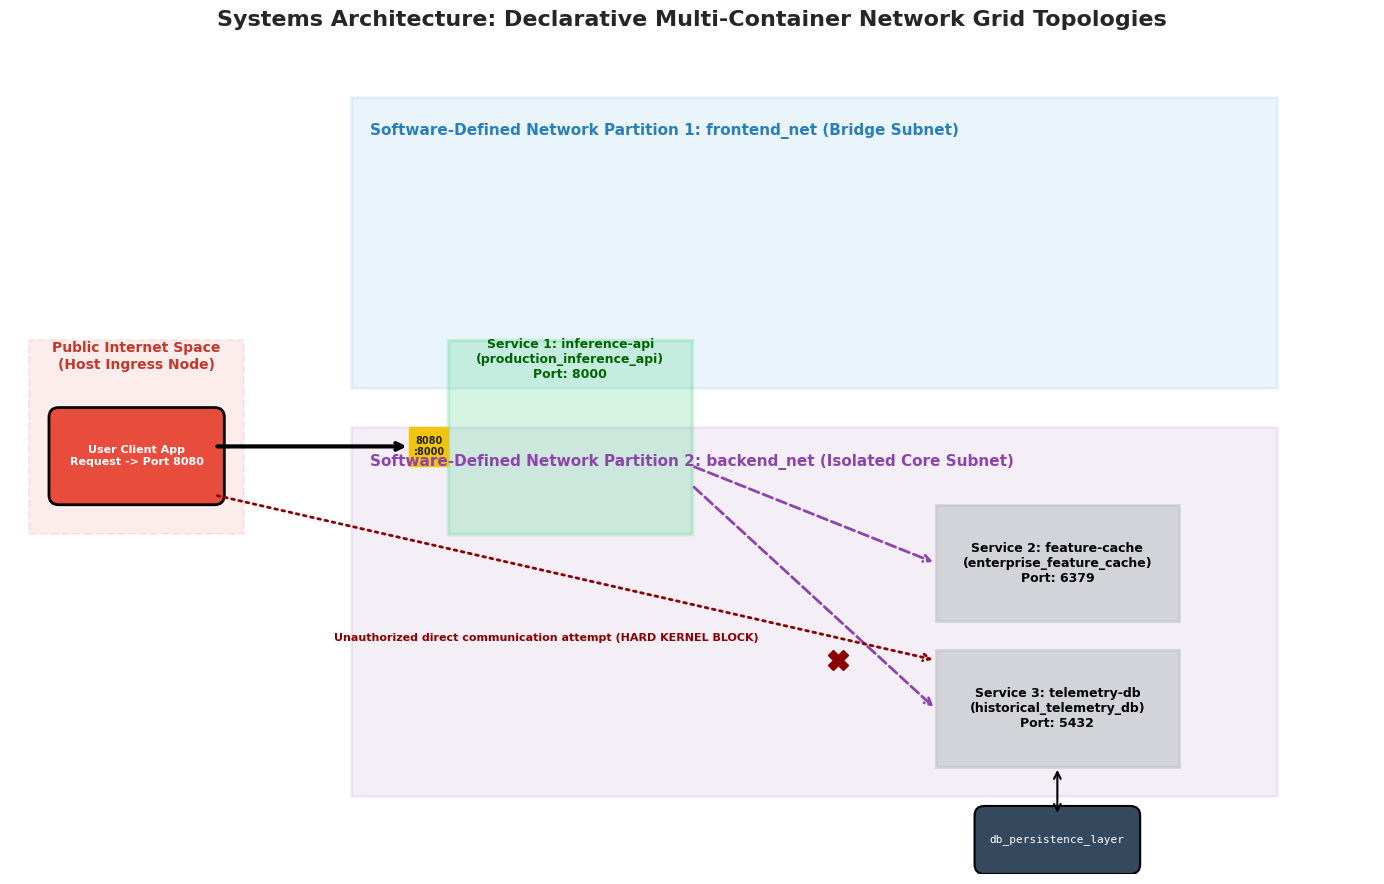

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create structural canvas layout
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle("Systems Architecture: Declarative Multi-Container Network Grid Topologies", fontsize=16, fontweight='bold')
ax.axis('off')

# 1. External Client Boundary (The Ingress Vector)
ax.add_patch(patches.Rectangle((0.2, 3.5), 2.2, 2.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(1.3, 5.2, "Public Internet Space\n(Host Ingress Node)", ha='center', color='#c0392b', fontweight='bold', fontsize=10)
ax.add_patch(patches.FancyBboxPatch((0.5, 3.9), 1.6, 0.8, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#e74c3c'))
ax.text(1.3, 4.3, "User Client App\nRequest -> Port 8080", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# 2. Frontend Network Bridge Partition (Public Facing Channel)
ax.add_patch(patches.Rectangle((3.5, 5.0), 9.5, 3.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2))
ax.text(3.7, 7.6, "Software-Defined Network Partition 1: frontend_net (Bridge Subnet)", ha='left', color='#2980b9', fontweight='bold', fontsize=11)

# 3. Backend Network Bridge Partition (Secure Isolated Channel)
ax.add_patch(patches.Rectangle((3.5, 0.8), 9.5, 3.8, fill=True, color='#9b59b6', alpha=0.1, edgecolor='black', linewidth=2))
ax.text(3.7, 4.2, "Software-Defined Network Partition 2: backend_net (Isolated Core Subnet)", ha='left', color='#8e44ad', fontweight='bold', fontsize=11)

# 4. Instantiated Container Vertices
# API Container (Bridges both worlds)
ax.add_patch(patches.Rectangle((4.5, 3.5), 2.5, 2.0, fill=True, color='#2ecc71', alpha=0.2, edgecolor='black', linewidth=2.5))
ax.text(5.75, 5.1, "Service 1: inference-api\n(production_inference_api)\nPort: 8000", ha='center', color='darkgreen', fontweight='bold', fontsize=9)
# Port junction representation markers
ax.add_patch(patches.Rectangle((4.1, 4.2), 0.4, 0.4, fill=True, color='#f1c40f', edgecolor='black'))
ax.text(4.3, 4.4, "8080\n:8000", ha='center', va='center', fontweight='bold', fontsize=7)

# Cache Container (Backend Only)
ax.add_patch(patches.Rectangle((9.5, 2.6), 2.5, 1.2, fill=True, color='#bdc3c7', alpha=0.6, edgecolor='black', linewidth=2))
ax.text(10.75, 3.2, "Service 2: feature-cache\n(enterprise_feature_cache)\nPort: 6379", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# DB Container (Backend Only)
ax.add_patch(patches.Rectangle((9.5, 1.1), 2.5, 1.2, fill=True, color='#bdc3c7', alpha=0.6, edgecolor='black', linewidth=2))
ax.text(10.75, 1.7, "Service 3: telemetry-db\n(historical_telemetry_db)\nPort: 5432", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Persistent storage anchor volume
ax.add_patch(patches.FancyBboxPatch((10.0, 0.1), 1.5, 0.5, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#34495e'))
ax.text(10.75, 0.35, "db_persistence_layer", ha='center', va='center', color='white', fontsize=8, fontfamily='monospace')

# 5. Connective Transmission Edges (Arrows)
# Port forward link vector
ax.annotate("", xy=(4.1, 4.4), xytext=(2.1, 4.4), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
# Container internal bridge channels
ax.annotate("", xy=(9.5, 3.2), xytext=(7.0, 4.2), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad", linestyle="--"))
ax.annotate("", xy=(9.5, 1.7), xytext=(7.0, 4.0), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad", linestyle="--"))
# Volumetric disk sync line
ax.annotate("", xy=(10.75, 0.6), xytext=(10.75, 1.1), arrowprops=dict(arrowstyle="<->", lw=1.5, color="black"))

# Threat Denial Marker representing strict backend network isolation
ax.plot([8.5], [2.2], marker='X', markersize=15, color='darkred', zorder=5)
ax.annotate("", xy=(9.5, 2.2), xytext=(2.1, 3.9), arrowprops=dict(arrowstyle="->", lw=2, color="darkred", linestyle='dotted'))
ax.text(5.5, 2.4, "Unauthorized direct communication attempt (HARD KERNEL BLOCK)", ha='center', color='darkred', fontweight='bold', fontsize=8)

plt.xlim(0, 14.0)
plt.ylim(0, 8.5)
plt.tight_layout()
plt.show()


## Real-World Use Case or Analogy:

Think of declarative orchestration via Docker Compose like **Designing a Master-Planned, High-Security Industrial Logistics Compound**:

* **The Single Container (The Standalone Warehouse):** In Lesson 08, you perfected the architecture of a single building. It has automated shelving, doors, and standard processing zones. It works perfectly on your blueprints.
* **The Multi-Container Grid (The Unified Industrial Compound):** In production, your factory cannot operate in complete isolation. You need a Processing Plant (**The Inference API**), a high-speed, temporary Loading Dock for cargo handling (**The Feature Cache**), and an underground, armored records vault to log transactions permanently (**The Telemetry Database**).
* **The Imperative Method (`docker run` Chaos):** Managing this setup manually is like building these three units on random vacant lots across a city, stringing loose phone wires across public tree branches to keep them talking, and leaving the bank vault doors open directly onto the public sidewalk. If a single building suffers a power surge, your coordinates change, the wires snap, and the compound collapses.
* **Docker Compose (The Master Architect Blueprint):** Docker Compose is your master blueprint for an isolated corporate compound.
* You buy an acre of land, erect a single security perimeter wall, and clear internal access channels.
* You build the Processing Plant right by the main gate (**The Port Mapping to Host Ingress**), allowing delivery drivers to access the front desk safely.
* You position the Loading Dock and the Armored Records Vault deep inside the compound, completely disconnected from the public street entrance (**Network Isolation**). The only way to access the vault is via internal paths monitored by security guards (**The CoreDNS Service Proxy Proxying**).
* You lay a foundation that links the records vault straight to a deep, concrete baseline storage anchor under the earth (**The Persistent Data Volume**). If a massive fire breaks out and destroys all the buildings above ground, the foundations remain safe. You run a command (`docker compose up`), and the entire city grid reconstructs itself identically above the data in seconds.